# Streaming language ID by distillation: the whole pipeline

This notebook walks through every stage using the repo's own code and the artifacts it produced.

| # | Stage | What you'll see |
|---|---|---|
| 1 | Data | what trains the student, what evaluates it, what a synthetic language switch looks like |
| 2 | Teachers | the 5-teacher bake-off and why the final teacher is an ensemble |
| 3 | **Targets** | the core of the assignment: what the teacher is allowed to hear for each student frame |
| 4 | Student | architecture, chunk mask, why lookahead is bounded |
| 5 | **Distillation step** | one real optimizer step: forward → KD loss → backward → step, no NaNs |
| 6 | Causality check | changing future audio doesn't change past outputs |
| 7 | **Streaming** | the shipped model fed 20 ms packets, routing decisions as they happen |
| 8 | Results | streaming accuracy, target-type ablation, silence-shortcut probe, commit policy |

Everything runs on CPU. Heavy steps (teachers, full training) are **not** re-run here; their outputs are loaded from `data/targets/`, `checkpoints/` and `results/`. The scripts that produced them are named in each section.

In [1]:
import json, sys, time
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(ROOT / "scripts"))

import numpy as np, torch, matplotlib.pyplot as plt
from IPython.display import Image, display
torch.set_num_threads(4); torch.manual_seed(0)

from slid.config import LANGS
from slid.audio import SR, load_wav, telephony
from slid.student import StreamingLID, load_student, chunk_mask, frame_end_sample, n_frames, FRAME_S
from slid.targets import grid_frames, teacher_inputs
from slid.metrics import frame_time, switch_lag
from slid.commit import commit_stream
from slid.streaming import StreamingSession

def read_jsonl(name):
    return [json.loads(l) for l in open(ROOT / f"data/manifests/{name}.jsonl", encoding="utf-8")]

BLUE, ORANGE, AQUA, YELLOW, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#6b6a64"
plt.rcParams.update({"figure.figsize": (9, 3.2), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e5df", "lines.linewidth": 2})
print("repo:", ROOT, "| languages:", LANGS)

/mnt/d/Work/Projects/asr-navana/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo: /mnt/d/Work/Projects/asr-navana | languages: ['hi', 'en', 'gu', 'mr', 'bn', 'ta', 'te']


## 1. Data

- **Monolingual:** FLEURS (read speech, 7 languages) plus **Svarah** (AI4Bharat, *Indian-accented* English).
- **Train/eval split:**
  - FLEURS `dev` split for training, `test` split for evaluation, so the sentences are disjoint.
  - Svarah is split by a demographic speaker key, since it has no speaker IDs.
- **Cleaning** (`scripts/clean_data.py`, after `scripts/prepare_data.py`):
  - Silero VAD keeps only speech.
  - Every clip is level-normalised to -23 dBFS.
- **Code-switching:** there's no real code-switched data, so we join **whole sentences** of different languages with a natural 0.25-0.6 s pause, at a *known* switch time. That makes switch lag measurable.

In [2]:
from collections import Counter
for split in ("train", "train_mix", "eval", "switch"):
    items = read_jsonl(split)
    hours = sum(it.get("dur", it["segments"][-1][2] if "segments" in it else 0) for it in items) / 3600
    print(f"{split:10s} {len(items):5d} clips  {hours:4.2f} h")
ev = read_jsonl("eval")
print("\neval clips per group:", dict(Counter("en-in" if it.get("source") == "svarah" else it["lang"] for it in ev)))
print("switch pairs:", dict(Counter(s["pair"] for s in read_jsonl("switch"))))

train       1599 clips  4.00 h
train_mix    600 clips  1.84 h
eval         480 clips  1.22 h
switch        90 clips  0.28 h

eval clips per group: {'hi': 60, 'en': 60, 'gu': 60, 'mr': 60, 'bn': 60, 'ta': 60, 'te': 60, 'en-in': 60}
switch pairs: {'hi->en': 10, 'en->hi': 10, 'hi->en-in': 10, 'en-in->hi': 10, 'gu->en': 10, 'mr->en': 10, 'bn->en': 10, 'ta->en': 10, 'te->en': 10}


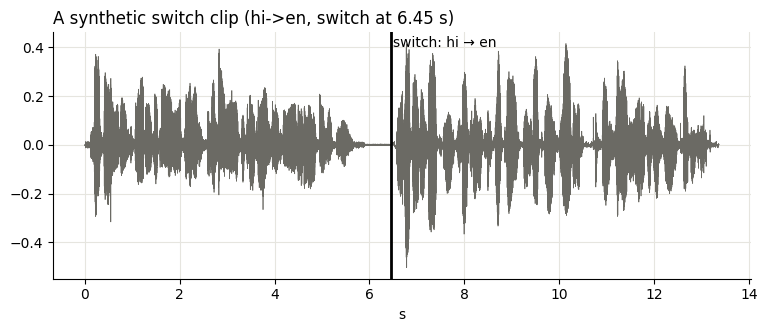

In [3]:
sw = next(s for s in read_jsonl("switch") if s["pair"] == "hi->en")
x_sw = load_wav(sw["path"])
t = np.arange(len(x_sw)) / SR
plt.plot(t, x_sw, color=GREY, lw=0.5)
plt.axvline(sw["switch_s"], color="k"); plt.text(sw["switch_s"] + 0.05, 0.8 * abs(x_sw).max(), "switch: hi → en")
plt.title(f"A synthetic switch clip ({sw['pair']}, switch at {sw['switch_s']:.2f} s)", loc="left"); plt.xlabel("s")
plt.show()

### A data bug we found by listening

The first version of the switch clips sounded wrong:
- The joins were abrupt: hard 4 s cuts.
- The English half was often nearly inaudible.

Measuring it: most FLEURS **US-English** recordings are ~30 dB quieter than every other language. The first model learned **"quiet => English"**. The cell below shows the level problem on the raw clips, and the model's behaviour before and after the fix.

In [4]:
def speech_level(x, fr=400):
    n = len(x) // fr; e = np.sqrt((x[: n * fr].reshape(n, fr) ** 2).mean(1)) + 1e-9
    return 20 * np.log10(np.percentile(e, 90))
raw, clean = {}, {}
for it in read_jsonl("eval"):
    g = "en-in" if it.get("source") == "svarah" else it["lang"]
    raw.setdefault(g, []).append(speech_level(load_wav(it["raw_path"])))
    clean.setdefault(g, []).append(speech_level(load_wav(it["path"])))
print("median speech level (dB)   raw    cleaned")
for g in sorted(raw):
    print(f"  {g:6s}                  {np.median(raw[g]):6.1f}   {np.median(clean[g]):6.1f}")
old = json.load(open(ROOT / "results/v1_data/final/level_test_v1model.json"))
new = json.load(open(ROOT / "results/final/level_test.json"))
print("\nsame clean eval audio, turned up/down: accuracy | non-English clips called English")
print("  gain    old model (un-normalised data)   new model")
for g in ("-30", "-20", "-10", "0", "10"):
    print(f"  {int(g):+3d} dB   {old['acc'][g]:.2f} | {old['called_english_non_en'][g]:.2f}                  "
          f"{new['acc'][g]:.2f} | {new['called_english_non_en'][g]:.2f}")

median speech level (dB)   raw    cleaned
  bn                       -24.7    -19.1
  en                       -56.4    -19.0
  en-in                    -17.3    -19.0
  gu                       -27.8    -19.2
  hi                       -25.8    -19.2
  mr                       -32.5    -19.4
  ta                       -23.2    -19.5
  te                       -25.9    -19.3

same clean eval audio, turned up/down: accuracy | non-English clips called English
  gain    old model (un-normalised data)   new model
  -30 dB   0.31 | 0.45                  0.53 | 0.16
  -20 dB   0.34 | 0.10                  0.79 | 0.05
  -10 dB   0.67 | 0.06                  0.88 | 0.01
   +0 dB   0.64 | 0.08                  0.90 | 0.01
  +10 dB   0.39 | 0.26                  0.90 | 0.01


## 2. Teachers: measured, not assumed

Choosing the teacher is part of the task, so five offline LID models were scored on the **same** 480 held-out clips (`scripts/teacher_bakeoff.py`). The five-way table below is on the original data (`results/v1_data/teachers/`). The two finalists and the ensemble were re-scored on the cleaned data.
- **Folding:** each teacher's posterior over its own label set (107 languages, 25, …) is folded onto our 7. Urdu goes into Hindi; everything else goes to "other".
- **Restriction:** the result is then **restricted** (renormalised) to the 7 languages.

In [5]:
rows = []
for t in ["ecapa", "ambernet", "xlsr-voxlingua", "whisper-turbo", "indic-transcribe"]:
    r = json.load(open(ROOT / f"results/v1_data/teachers/{t}.json")); c = r["by_condition"]["clean"]
    rows.append((t + " (orig)", *[c[k]["acc_restricted"] for k in ("0.5s", "1s", "2s", "full")],
                 r["by_condition"]["telephony"]["full"]["acc_restricted"], c["full"]["acc_by_lang"]["en-in"],
                 c["3s"]["ece_restricted"]))
for t in ["indic-transcribe", "whisper-turbo", "ensemble"]:
    r = json.load(open(ROOT / f"results/teachers/{t}.json")); c = r["by_condition"]["clean"]
    rows.append((t + " (CLEAN)", *[c[k]["acc_restricted"] for k in ("0.5s", "1s", "2s", "full")],
                 r["by_condition"]["telephony"]["full"]["acc_restricted"], c["full"]["acc_by_lang"]["en-in"],
                 c["3s"]["ece_restricted"]))
print(f"{'teacher':26s} {'0.5s':>5s} {'1s':>5s} {'2s':>5s} {'full':>5s} {'phone':>6s} {'en-IN':>6s} {'ECE3s':>6s}")
for r in rows:
    print(f"{r[0]:26s} " + " ".join(f"{v:5.2f}" for v in r[1:5]) + f" {r[5]:6.2f} {r[6]:6.2f} {r[7]:6.3f}")

teacher                     0.5s    1s    2s  full  phone  en-IN  ECE3s
ecapa (orig)                0.20  0.31  0.64  0.87   0.82   0.13  0.115
ambernet (orig)             0.20  0.35  0.65  0.87   0.84   0.03  0.111
xlsr-voxlingua (orig)       0.21  0.36  0.66  0.92   0.90   0.38  0.061
whisper-turbo (orig)        0.25  0.28  0.41  0.61   0.57   1.00  0.355
indic-transcribe (orig)     0.18  0.43  0.81  0.90   0.90   0.20  0.067
indic-transcribe (CLEAN)    0.60  0.75  0.86  0.90   0.90   0.18  0.076
whisper-turbo (CLEAN)       0.26  0.35  0.45  0.59   0.57   1.00  0.360
ensemble (CLEAN)            0.54  0.76  0.93  0.96   0.96   0.72  0.014


**Findings:**
- **Short audio is hard for every teacher,** and on the original data it looked worse than it is: "1 s" included leading silence. On speech-only audio Indic-Transcribe goes from .43 to .75 at 1 s.
- **The VoxLingua teachers (ECAPA, AmberNet, XLS-R) can't recognise Indian English** (en-IN 3-38%).
- **Indic-Transcribe labels Indian English as the speaker's native language** (Marathi speaker -> "mr").
- **Whisper is perfect on English and Indian English**, but misses Marathi, Gujarati, Bengali and Telugu.
- **They fail on opposite cases, so we ensemble them:** log q ∝ w·log q_IndicT + (1-w)·log q_Whisper. *w* is tuned on the **training** pool, never eval (`scripts/ensemble.py`); on the cleaned data w = 0.65.

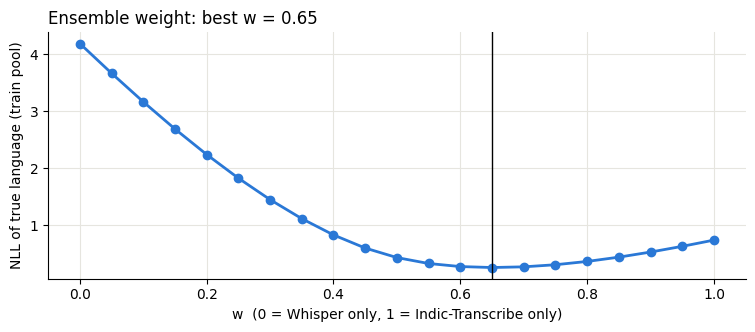

In [6]:
tun = json.load(open(ROOT / "results/teachers/ensemble_tuning.json"))
w = [g["w"] for g in tun["grid"]]; nll = [g["nll"] for g in tun["grid"]]
plt.plot(w, nll, marker="o", color=BLUE); plt.axvline(tun["best"]["w"], color="k", lw=1)
plt.xlabel("w  (0 = Whisper only, 1 = Indic-Transcribe only)"); plt.ylabel("NLL of true language (train pool)")
plt.title(f"Ensemble weight: best w = {tun['best']['w']}", loc="left"); plt.show()

## 3. Targets: the core of the assignment

The teacher hears the whole clip; the student at time *t* has only heard audio up to *t*. For each student frame *t*, **which audio is the teacher allowed to hear when producing the target?**

Let e(t) be the last input sample that student frame t depends on:

| kind | teacher hears | uses future audio? |
|---|---|---|
| `full` | the whole clip | yes |
| `centred` | e−1.5 s … e+1.5 s | yes, 1.5 s |
| `prefix` | 0 … e | **no** |
| `causal` (shipped) | e−3 s … e | **no**, and it forgets old audio |

With KL loss the best possible student outputs **E[target ∣ audio heard so far]**. The leftover loss is zero **only** if the target uses nothing beyond the heard audio.

Below: the exact sample ranges for one frame, then all four target types plotted over the switch clip from §1.

In [7]:
T = n_frames(len(x_sw)); fr = grid_frames(len(x_sw), every=4, min_s=0.4)
t_demo = fr[len(fr) // 2]; e = frame_end_sample(int(t_demo))
print(f"student frame {t_demo}: emitted at {e/SR:.2f} s (it has heard samples [0, {e}))")
for kind in ("prefix", "causal", "centered"):
    seg_idx = teacher_inputs(np.arange(len(x_sw)), np.array([t_demo]), kind, window_s=3.0)[0]
    print(f"  {kind:9s} teacher hears {seg_idx[0]/SR:5.2f} s → {(seg_idx[-1]+1)/SR:5.2f} s"
          + ("   <-- beyond what the student has heard" if seg_idx[-1] >= e else ""))

student frame 87: emitted at 6.99 s (it has heard samples [0, 111760))
  prefix    teacher hears  0.00 s →  6.99 s
  causal    teacher hears  3.98 s →  6.99 s
  centered  teacher hears  5.49 s →  8.48 s   <-- beyond what the student has heard


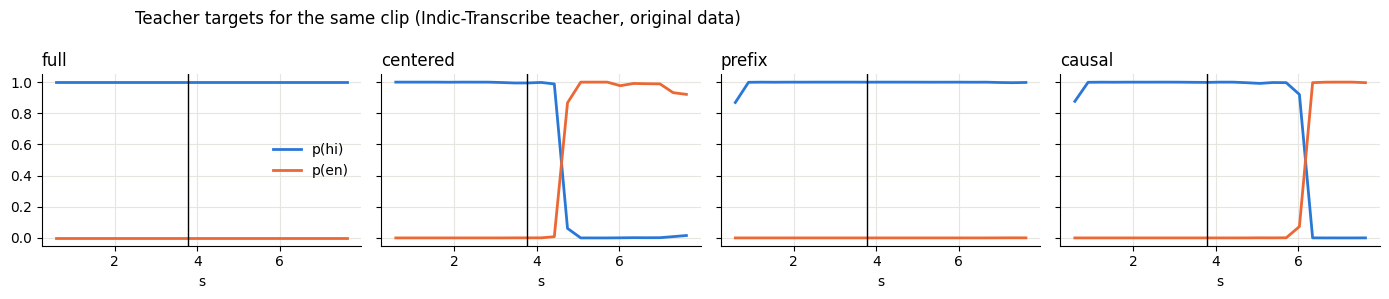

In [8]:
# The 4 target kinds were built for the target comparison, which ran on the original data,
# so this illustration uses the original (un-cleaned) version of a hi->en switch clip.
sw1 = next(json.loads(l) for l in open(ROOT / "data/manifests_v1/switch.jsonl") if '"hi->en"' in l)
fig, axes = plt.subplots(1, 4, figsize=(14, 3), sharey=True)
hi, en = LANGS.index("hi"), LANGS.index("en")
for ax, kind in zip(axes, ("full", "centered", "prefix", "causal")):
    f, q = torch.load(ROOT / f"data/targets_v1/indic-transcribe/{kind}.pt")[sw1["path"]]
    tt = frame_time(f.numpy())
    ax.plot(tt, q[:, hi], color=BLUE, label="p(hi)"); ax.plot(tt, q[:, en], color=ORANGE, label="p(en)")
    ax.axvline(sw1["switch_s"], color="k", lw=1); ax.set_title(kind, loc="left"); ax.set_xlabel("s")
axes[0].legend(frameon=False); fig.suptitle("Teacher targets for the same clip (Indic-Transcribe teacher, original data)", x=0.1, ha="left")
plt.tight_layout(); plt.show()

**How to read it:**
- **`full`:** one label for the whole clip, wrong for half of it.
- **`centred`:** flips *at* the switch; to match it, the student must see 1.5 s ahead.
- **`prefix`:** keeps hearing the old Hindi, so it is slow to switch.
- **`causal`:** switches once most of its 3 s window is English. That delay (≈ W/2) is the honest price of never seeing the future.

## 4. Student

```
audio → log-mel (25 ms / 10 ms, center=False) → fixed train-set CMVN
      → 3 causal stride-2 convs (80 ms frames, d=144)
      → 6 Conformer blocks (FFN, chunk-masked 4-head attention, causal depthwise conv k=15, FFN)
      → linear → 7 languages
```

It's a **new** small architecture, trained from random init **only** on teacher outputs; it never sees true labels. Its lookahead is bounded by the **chunk mask**: a frame may attend to its own chunk and everything before it, but never beyond its chunk. Every layer obeys the same boundary, so stacking layers doesn't add lookahead.

total params: 3.06 M
  front end (subsampling)    0.159 M
  6 conformer blocks         2.900 M
  head                       0.001 M


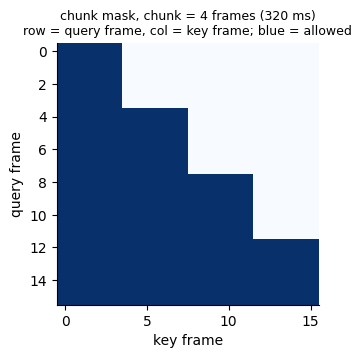

In [9]:
m = StreamingLID(len(LANGS))
count = lambda mod: sum(p.numel() for p in mod.parameters())
print(f"total params: {count(m)/1e6:.2f} M")
for name, mod in [("front end (subsampling)", m.sub), ("6 conformer blocks", m.blocks), ("head", m.head)]:
    print(f"  {name:26s} {count(mod)/1e6:.3f} M")

mask = chunk_mask(16, chunk=4)
plt.figure(figsize=(3.6, 3.4)); plt.imshow(~mask, cmap="Blues")
plt.title("chunk mask, chunk = 4 frames (320 ms)\nrow = query frame, col = key frame; blue = allowed", fontsize=9)
plt.xlabel("key frame"); plt.ylabel("query frame"); plt.grid(False); plt.show()

## 5. One real distillation step

Real audio, real **ensemble causal** targets, the training code from `scripts/train.py`:

```
KL( q_t || softmax(student(x)[t]) )   averaged over the target frames of the batch
```

Half the batch goes through the **telephony simulation**, but its target stays the teacher's answer on the *clean* audio. After the single required step, we take 30 more steps on the same batch; the loss should fall, which shows the plumbing is correct.

batch: 6 clips x 8.0 s, 136 target frames, targets sum to 1.000


STEP 1: loss 2.4090  grad-norm 18.293  finite=True  all grads finite=True


after 31 steps on this batch: loss 2.409 -> 0.035


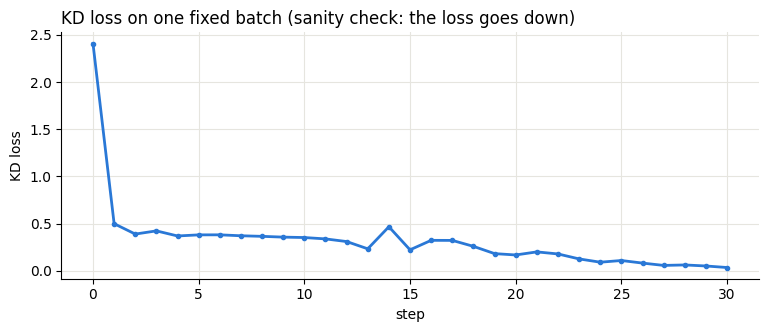

In [10]:
import random
from train import make_batch, kd_loss, fit_cmvn
targets = torch.load(ROOT / "data/targets/ensemble/causal.pt")
pool = read_jsonl("train")[:40:10] + read_jsonl("train_mix")[:2]
clips = {"path": [it["path"] for it in pool], "wav": [load_wav(it["path"]) for it in pool]}

torch.manual_seed(0); random.seed(0)
model = StreamingLID(len(LANGS))
fit_cmvn(model, clips["wav"], "cpu")
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
wav, rows, frames, q = make_batch(clips, targets, max_s=8.0, tel_p=0.5, rng=random.Random(0))
print(f"batch: {wav.shape[0]} clips x {wav.shape[1]/SR:.1f} s, {len(rows)} target frames, targets sum to {q.sum(1).mean():.3f}")

losses = []
for step in range(31):
    logits = model(wav, chunk=4)
    loss = kd_loss(logits, rows, frames, q)
    opt.zero_grad(); loss.backward()
    gnorm = torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0).item()
    opt.step(); losses.append(loss.item())
    if step == 0:
        print(f"STEP 1: loss {loss.item():.4f}  grad-norm {gnorm:.3f}  finite={torch.isfinite(loss).item()}  "
              f"all grads finite={all(torch.isfinite(p.grad).all() for p in model.parameters() if p.grad is not None)}")
print(f"after 31 steps on this batch: loss {losses[0]:.3f} -> {losses[-1]:.3f}")
plt.plot(losses, color=BLUE, marker="o", ms=3); plt.xlabel("step"); plt.ylabel("KD loss")
plt.title("KD loss on one fixed batch (sanity check: the loss goes down)", loc="left"); plt.show()

The target-type comparison (`scripts/train.py`, 5,000 steps each, original data) gives the held-out curves below. Each target type is plotted against its own targets; the plateau height is the part of that target the student *cannot* learn.

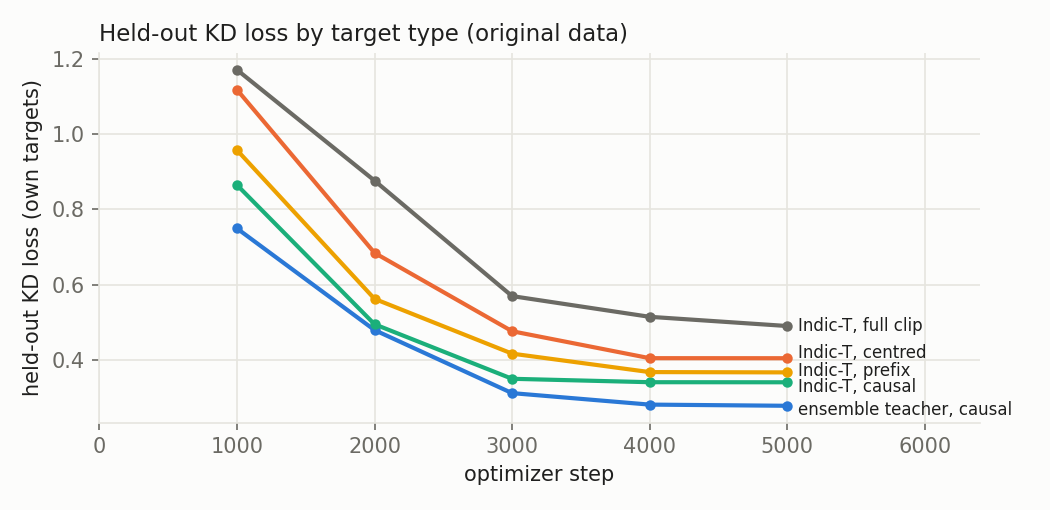

In [11]:
display(Image(str(ROOT / "results/figures/heldout_kd.png")))

## 6. Causality check

Replace all audio after the end of one chunk with noise. Every output up to that chunk must stay **exactly** the same. This uses the shipped model.

In [12]:
final = load_student(ROOT / "checkpoints/final/student.pt")
x = torch.from_numpy(x_sw)[None]
for chunk in (1, 2, 4, 8):
    Tn = n_frames(x.shape[1]); t_end = chunk * (Tn // (2 * chunk)) - 1
    cut = frame_end_sample(t_end)
    y = x.clone(); y[:, cut:] = torch.randn_like(y[:, cut:])
    with torch.no_grad():
        a, b = final(x, chunk), final(y, chunk)
    print(f"chunk {chunk*80:3d} ms: max change in frames <= {t_end}: {(a[:, :t_end+1]-b[:, :t_end+1]).abs().max():.2e}   "
          f"(frames after it DO change: {(a[:, t_end+1:]-b[:, t_end+1:]).abs().max():.2f})")

chunk  80 ms: max change in frames <= 82: 0.00e+00   (frames after it DO change: 6.16)
chunk 160 ms: max change in frames <= 81: 0.00e+00   (frames after it DO change: 6.02)
chunk 320 ms: max change in frames <= 79: 0.00e+00   (frames after it DO change: 6.09)
chunk 640 ms: max change in frames <= 79: 0.00e+00   (frames after it DO change: 6.17)


## 7. Streaming: the shipped model on a live-like stream

`StreamingSession.push(samples)` keeps a key/value cache per layer, a small convolution state and a short audio buffer. We feed the switch clip in **20 ms packets**, as a phone call arrives. Then:
1. We check the stream gives the same output as the whole-clip forward.
2. We apply the commit policy (smoothing + θ = 0.8 + 240 ms dwell).

13.4 s of audio in 668 packets -> 164 posteriors in 137 ms (RTF 0.0103); max |stream - batch| = 8.0e-07
routing decisions: 2.02s -> hi, 8.98s -> en
true switch at 6.45s; committed switch lag = 2.53s


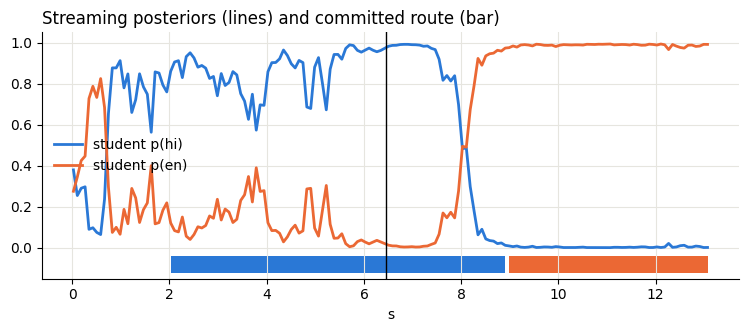

In [13]:
sess = StreamingSession(final, chunk=4)
t0 = time.time()
post = np.concatenate([sess.push(x_sw[i:i + SR // 50]) for i in range(0, len(x_sw), SR // 50)])
dt = time.time() - t0
with torch.no_grad():
    ref = final(torch.from_numpy(x_sw)[None], 4)[0].softmax(-1).numpy()[: len(post)]
print(f"{len(x_sw)/SR:.1f} s of audio in {len(x_sw)//(SR//50)} packets -> {len(post)} posteriors in {dt*1000:.0f} ms "
      f"(RTF {dt/(len(x_sw)/SR):.4f}); max |stream - batch| = {np.abs(post-ref).max():.1e}")

com = commit_stream(post, theta_commit=0.8, theta_switch=0.9, dwell=3)
tt = frame_time(np.arange(len(post)))
changes = [(tt[i], LANGS[com[i]]) for i in range(len(com)) if com[i] >= 0 and (i == 0 or com[i] != com[i-1])]
print("routing decisions:", ", ".join(f"{t:.2f}s -> {l}" for t, l in changes))
print(f"true switch at {sw['switch_s']:.2f}s; committed switch lag = {switch_lag(np.arange(len(post)), com, en, sw['switch_s']):.2f}s")

plt.plot(tt, post[:, hi], color=BLUE, label="student p(hi)"); plt.plot(tt, post[:, en], color=ORANGE, label="student p(en)")
for k, c in ((hi, BLUE), (en, ORANGE)):
    plt.fill_between(tt, -0.12, -0.04, where=com == k, color=c, step="post", lw=0)
plt.axvline(sw["switch_s"], color="k", lw=1); plt.ylim(-0.15, 1.05); plt.legend(frameon=False, loc="center left")
plt.title("Streaming posteriors (lines) and committed route (bar)", loc="left"); plt.xlabel("s"); plt.show()

In [14]:
# the same clip over a simulated phone line (300-3400 Hz, 8 kHz mu-law, 20 dB noise)
x_tel = telephony(x_sw, seed=0)[: len(x_sw)]
with torch.no_grad():
    p_tel = final(torch.from_numpy(x_tel)[None], 4)[0].softmax(-1).numpy()
c_tel = commit_stream(p_tel, theta_commit=0.8, theta_switch=0.9, dwell=3)
print("telephony routing:", ", ".join(f"{frame_time([i])[0]:.2f}s -> {LANGS[c_tel[i]]}" for i in range(len(c_tel))
                                        if c_tel[i] >= 0 and (i == 0 or c_tel[i] != c_tel[i-1])))

telephony routing: 3.06s -> en, 6.34s -> hi, 8.82s -> en


## 8. Results

In [15]:
r = json.load(open(ROOT / "results/final/final_eval.json"))
print("FINAL MODEL, held-out (480 monolingual clips): accuracy at wall-clock time after start")
print(f"{'chunk':>8s} {'0.5s':>5s} {'1s':>5s} {'2s':>5s} {'3s':>5s} {'end':>5s} {'phone':>6s} {'ECE':>6s} {'agree':>6s}")
for ch, v in r["by_chunk"].items():
    c = v["clean"]
    print(f"{v['lookahead_ms']:>6d}ms " + " ".join(f"{c['acc_at'][k]:5.2f}" for k in ("0.5s", "1s", "2s", "3s"))
          + f" {c['acc_end']:5.2f} {v['telephony']['acc_end']:6.2f} {c['ece_end']:6.3f} {c['teacher_agreement_causal']:6.2f}")
print(f"params {r['n_params']/1e6:.2f}M, CPU RTF (1 thread) {r['cpu_rtf_1thread']:.4f}")

FINAL MODEL, held-out (480 monolingual clips): accuracy at wall-clock time after start
   chunk  0.5s    1s    2s    3s   end  phone    ECE  agree
    80ms  0.29  0.68  0.84  0.89  0.91   0.84  0.032   0.83
   160ms  0.30  0.70  0.84  0.89  0.90   0.84  0.033   0.83
   320ms  0.35  0.71  0.86  0.89  0.90   0.84  0.034   0.83
   640ms  0.36  0.72  0.85  0.88  0.90   0.83  0.037   0.83
params 3.06M, CPU RTF (1 thread) 0.0015


**Target-type ablation** (Indic-Transcribe teacher, same student, 5,000 steps each, original data: every arm saw the same loudness shortcut, so the differences are about the targets) and the **silence-shortcut probe**: accuracy when the student hears only the leading silence of a clip, where chance is 1/7 = 0.14.

In [16]:
sil = json.load(open(ROOT / "results/final/silence_test.json"))["models"]
print(f"{'target':9s} {'acc@1s':>7s} {'end':>5s} {'phone':>6s} {'missed switches':>16s} {'acc on SILENCE':>15s}")
for k in ("full", "centered", "hybrid", "prefix", "causal"):
    v = json.load(open(ROOT / f"results/v1_data/ablation/eval_{k}.json"))["by_chunk"]["4"]
    miss = sum(d["missed_committed"] for d in v["switch"].values())
    print(f"{k:9s} {v['clean']['acc_at']['1s']:7.2f} {v['clean']['acc_end']:5.2f} {v['telephony']['acc_end']:6.2f} "
          f"{miss:>12d}/90 {sil['indic-transcribe_' + k]['acc_on_silence']:15.2f}")
print(f"\nshipped final model (clean data, ensemble, causal) on silence: {sil['final']['acc_on_silence']:.2f};  ensemble centred: {sil['ensemble_centered']['acc_on_silence']:.2f}")

target     acc@1s   end  phone  missed switches  acc on SILENCE
full         0.75  0.85   0.77           78/90            0.62
centered     0.81  0.85   0.75           42/90            0.73
hybrid       0.75  0.88   0.74           38/90            0.68
prefix       0.62  0.89   0.80           69/90            0.10
causal       0.58  0.89   0.83           41/90            0.14

shipped final model (clean data, ensemble, causal) on silence: 0.12;  ensemble centred: 0.64


**Reading it:**
- **Future-informed targets (full, centred, hybrid) look better at 1 s**, but they also "recognise" the language from **silence** (62–73%). They learned FLEURS recording conditions: a target that depends on unheard audio rewards any clue that predicts it.
- **Information-matched targets (prefix, causal) stay at chance on silence.**
- **Full and prefix cannot follow switches.**
- Causal is the only target that is honest *and* can switch, so it ships.

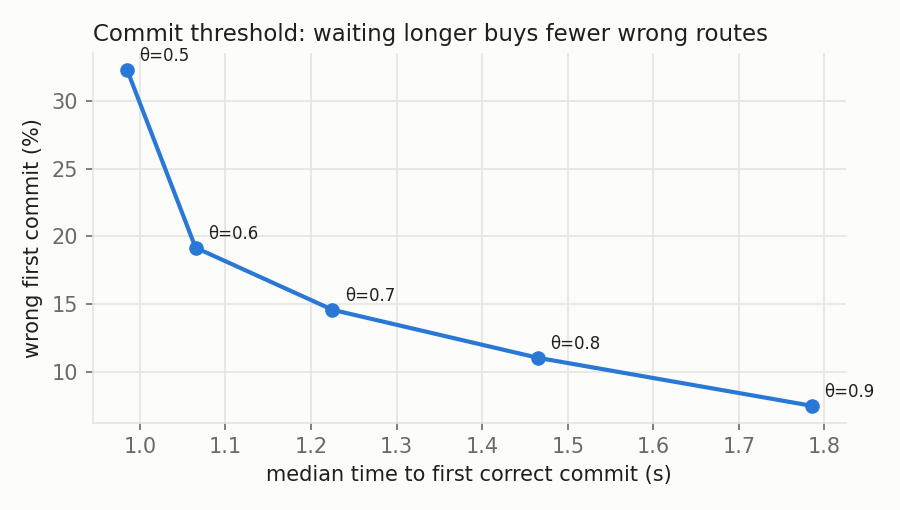

In [17]:
display(Image(str(ROOT / "results/figures/commit_tradeoff.png")))

In [18]:
tr = json.load(open(ROOT / "results/final/turn_reset_final.json"))
print("turn-boundary reset (clean switch clips, sentence + natural pause + sentence, theta 0.8):")
for k in ("none", "policy", "state"):
    print(f"  {k:7s} committed lag {tr[k]['switch_lag_median_s']:.2f}s  missed {tr[k]['missed']}/90  premature {tr[k]['premature_rate']:.2f}")
print("\nteacher window W (original data):")
for n, label in (("v2_ensemble_causal_left64", "W = 3 s"), ("v2_ensemble_causal_w1.5", "W = 1.5 s")):
    v = json.load(open(ROOT / f"results/v1_data/variants/{n}_eval.json"))["by_chunk"]["4"]
    lag = np.nanmedian([d["raw"] for d in v["switch"].values()])
    print(f"  {label}: student raw switch lag {lag:.2f}s, end acc {v['clean']['acc_end']:.2f}, phone {v['telephony']['acc_end']:.2f}")

turn-boundary reset (clean switch clips, sentence + natural pause + sentence, theta 0.8):
  none    committed lag 2.69s  missed 29/90  premature 0.00
  policy  committed lag 2.69s  missed 29/90  premature 0.00
  state   committed lag 0.95s  missed 16/90  premature 0.00

teacher window W (original data):
  W = 3 s: student raw switch lag 2.07s, end acc 0.87, phone 0.80
  W = 1.5 s: student raw switch lag 1.14s, end acc 0.71, phone 0.66


**The VAD-gated turn pipeline** (DESIGN §1):
- Silero VAD cuts the switch clips into turns, and every turn gets a fresh student stream.
- The **early route** (first commit) picks which ASR streams partials.
- The **final LID at the endpoint** is what the bot acts on. If it differs from the early route, the buffered turn is re-decoded.

In [19]:
te = json.load(open(ROOT / "results/final/turn_eval.json"))
old = json.load(open(ROOT / "results/v1_data/final/turn_eval_v1model.json"))
print(f"{'':32s} {'old model':>10s} {'new model':>10s}")
for k, label in (("final_lid_acc", "final LID at endpoint"), ("early_route_rate", "turns with an early route"),
                 ("early_route_time_median_s", "early route median time (s)"), ("early_route_acc", "early route accuracy"),
                 ("redecode_rate", "re-decode needed")):
    print(f"{label:32s} {old[k]:10.3f} {te[k]:10.3f}")
print(f"({te['n_turns']} turns)")

                                  old model  new model
final LID at endpoint                 0.715      0.945
turns with an early route             0.520      0.855
early route median time (s)           2.265      1.225
early route accuracy                  0.856      0.936
re-decode needed                      0.040      0.030
(200 turns)


## Summary

- **Teacher:** a measured choice. An ensemble of Indic-Transcribe and Whisper, because their errors are complementary. It is frozen and only labels audio.
- **Data:** listening to the clips exposed a loudness shortcut ("quiet => English"). We fixed it at the data level:
  - VAD trimming
  - level normalisation
  - conversational switch clips
  - random-gain augmentation
- **Student:** a 3 M-parameter causal chunked Conformer, trained **only** on teacher posteriors. It's truly streaming (KV-cache session, equal to the batch forward) and runs at ~0.002x real time on one CPU thread.
- **The asymmetry:** the target for student frame *t* uses **only audio the student has heard** (a causal 3 s window). Measured alternatives that peek at the future learn a recording-condition shortcut (the silence probe) or cannot follow switches.
- **In the VAD turn pipeline:**
  - the final language is right at the end of ~95% of turns
  - an early route happens after ~1.2 s of speech
  - a switch between turns is followed in < 1 s
- **Part 2** (`DESIGN.md`): turning the posterior stream into ASR routing decisions: commit policy, routing cost, turn resets, fallback, and the teacher-relabel loop.